# Trabajo Práctico Final — Visión por Computadora II (CEIA)
# Clasificación y Segmentación de Residuos Reciclables

**Integrantes:** Completar con nombres del equipo (3-4 personas)

Este notebook documenta el proceso completo del proyecto de punta a punta:
desde el análisis exploratorio del dataset hasta la evaluación del modelo
entrenado y su prueba sobre imágenes nuevas. Cada decisión técnica se
justifica en el texto antes de la celda de código correspondiente.

El código reutilizable (funciones de inferencia, mapeo de colores, selección
de dispositivo) vive en `src/` y `data/`, y se importa acá para no duplicar
lógica — pero el flujo completo se puede seguir y ejecutar celda por celda
desde este mismo notebook.


## 0.1. Instalación de dependencias

Corré esta celda una sola vez (o cuando cambien las dependencias). Si ya
instalaste todo desde terminal con `pip install -r requirements.txt`, podés
saltear esta celda sin problema — no rompe nada volver a correrla, `pip`
detecta lo que ya está instalado.


In [1]:
!pip install -q -r ../requirements.txt



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 0.2. Descarga del dataset (TACO)

Esta celda clona el repo de TACO y descarga las imágenes desde Flickr.
**Puede tardar varios minutos** (descarga imagen por imagen). Si ya lo
corriste antes, el script detecta que `data/TACO/` ya existe y no vuelve a
descargar todo de cero.


In [2]:
import os
import time
from io import BytesIO
from pathlib import Path

import requests
from PIL import Image

ANNOTATIONS_PATH = Path("../data/TACO/data/annotations.json")
FAILED_LOG_PATH = Path("../data/TACO/data/failed_downloads.log")

import json
with open(ANNOTATIONS_PATH, "r") as f:
    annotations = json.load(f)

images = annotations["images"]
total = len(images)
ok_count = 0
skip_count = 0
fail_count = 0
failed = []

for i, image in enumerate(images):
    file_name = image["file_name"]
    url_original = image["flickr_url"]
    file_path = ANNOTATIONS_PATH.parent / file_name

    subdir = file_path.parent
    subdir.mkdir(parents=True, exist_ok=True)

    if file_path.is_file():
        skip_count += 1
    else:
        try:
            response = requests.get(url_original, timeout=15)
            img = Image.open(BytesIO(response.content))
            if img._getexif():
                img.save(file_path, exif=img.info["exif"])
            else:
                img.save(file_path)
            ok_count += 1
        except Exception as e:
            fail_count += 1
            failed.append((file_name, url_original, str(e)))

    if (i + 1) % 5 == 0 or (i + 1) == total:
        print(f"Progreso: {i + 1}/{total} | OK: {ok_count} | Ya existían: {skip_count} | Fallidas: {fail_count}", end="\r", flush=True)

print(f"\n\n✅ Terminado. OK: {ok_count} | Ya existían: {skip_count} | Fallidas: {fail_count} de {total}")

if failed:
    with open(FAILED_LOG_PATH, "w") as f:
        for file_name, url, err in failed:
            f.write(f"{file_name}\t{url}\t{err}\n")
    print(f"Log de fallidas guardado en: {FAILED_LOG_PATH}")


Progreso: 1500/1500 | OK: 0 | Ya existían: 1500 | Fallidas: 0

✅ Terminado. OK: 0 | Ya existían: 1500 | Fallidas: 0 de 1500


## 0.3. Preparación del dataset (agrupar categorías + convertir a YOLO-seg)

Agrupa las 60 categorías finas de TACO en las 6 clases macro del proyecto,
y convierte las anotaciones de formato COCO a formato YOLO-seg. Al final
imprime la distribución de instancias por clase macro — revisar acá que
ninguna quede muy desbalanceada.


In [3]:
import shutil
from pathlib import Path

# Si ya habías preparado el dataset antes (parcial), lo borramos para
# regenerarlo de cero con el set completo de imágenes descargadas.
taco_yolo_dir = Path("../data/taco_yolo")
if taco_yolo_dir.exists():
    shutil.rmtree(taco_yolo_dir)
    print("Carpeta data/taco_yolo anterior eliminada, se regenera de cero.")
else:
    print("No había una carpeta data/taco_yolo previa, se crea de cero.")


Carpeta data/taco_yolo anterior eliminada, se regenera de cero.


In [4]:
!python ../data/prepare_dataset.py


Cargando anotaciones COCO...
[prepare_dataset] 3 categorías sin mapeo explícito, asignadas a 'otros'. Revisar si conviene remapear alguna manualmente:
   - id=48 name='Plastic glooves' supercategory='Plastic glooves'
   - id=49 name='Plastic utensils' supercategory='Plastic utensils'
   - id=51 name='Rope & strings' supercategory='Rope & strings'

✅ Dataset preparado en formato YOLO-seg.
   Salida: /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/notebooks/../data/taco_yolo
   data.yaml: /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/notebooks/../data/taco_yolo/data.yaml

Imágenes: train=1202, val=298

Distribución de instancias por clase macro (train / val):
   plastico       : train= 2167  val=  504  (19% en val)
   papel_carton   : train=  346  val=   88  (20% en val)
   vidrio         : train=  142  val=    6  (4% en val)
   metal          : train=  368  val=   88  (19% en val)
   organico       :

## 0.3.1. Verificación: confirmar qué quedó realmente en disco

Chequeo directo de los archivos de etiquetas ya generados, para confirmar
que la preparación del dataset sí reflejó las imágenes descargadas más
recientes (y no una versión vieja/parcial en caso de haber corrido las
celdas fuera de orden).


In [5]:
from pathlib import Path
from collections import Counter

MACRO_CLASSES = ["plastico", "papel_carton", "vidrio", "metal", "organico", "otros"]
counts = Counter()

for split in ["train", "val"]:
    labels_dir = Path(f"../data/taco_yolo/labels/{split}")
    for label_file in labels_dir.glob("*.txt"):
        for line in label_file.read_text().splitlines():
            if line.strip():
                class_id = int(line.split()[0])
                counts[MACRO_CLASSES[class_id]] += 1

print("Instancias actuales en disco (train+val):")
for c in MACRO_CLASSES:
    print(f"  {c}: {counts.get(c, 0)}")


Instancias actuales en disco (train+val):
  plastico: 2671
  papel_carton: 434
  vidrio: 148
  metal: 456
  organico: 8
  otros: 1321


In [6]:
from pathlib import Path

for cache in Path("../data/taco_yolo/labels").glob("*.cache"):
    cache.unlink()
    print(f"Borrado: {cache}")


## 0.4. Imports y detección de dispositivo

Instalamos dependencias e importamos las funciones reutilizables del repo.
Detectamos automáticamente el dispositivo disponible: CUDA (GPU NVIDIA),
MPS (GPU de Mac con Apple Silicon) o CPU.


In [7]:
# Las dependencias ya se instalaron en la celda 0.1 de más arriba.

import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))
sys.path.append(str(Path("../data").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import cv2

from device_utils import get_device, get_device_str

device = get_device()
device_str = get_device_str()
print(f"Dispositivo detectado: {device} (string para Ultralytics: '{device_str}')")


[device_utils] Usando MPS (GPU de Apple Silicon)
Dispositivo detectado: mps (string para Ultralytics: 'mps')


## 1. Weights & Biases: setup de tracking de experimentos

Usamos W&B para registrar hiperparámetros, métricas por época y comparar
corridas entre los distintos integrantes del equipo. Es complementario a
ver los gráficos inline en este notebook: acá los vemos para esta corrida
puntual, y en el dashboard de W&B comparamos entre todas las corridas del
equipo (distintos hiperparámetros, distintos modelos base, etc.).

**Nota:** la primera vez que corras `wandb.login()` te va a pedir un API key
(gratis, se obtiene en https://wandb.ai/authorize). Se guarda localmente,
no hace falta loguearse de nuevo en corridas siguientes desde la misma máquina.


In [8]:
import wandb

wandb.login()  # pide el API key la primera vez, después queda guardado localmente

WANDB_PROJECT = "residuos-segmentacion"


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: fefe_fernandez (fefe_fernandez-quarcks-alchemist) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Análisis Exploratorio del Dataset (EDA)

Usamos TACO (Trash Annotations in Context), que distribuye sus anotaciones
en formato COCO (un único `annotations.json`, no carpetas por clase). El EDA
completo y detallado está en `notebooks/01_EDA_TACO.ipynb`; acá resumimos
los hallazgos clave que justifican las decisiones de preprocesamiento.


In [9]:
import json
from collections import Counter

TACO_DIR = Path("../data/TACO/data")
ANNOTATIONS_PATH = TACO_DIR / "annotations.json"

with open(ANNOTATIONS_PATH) as f:
    coco = json.load(f)

print("Imágenes:", len(coco["images"]))
print("Anotaciones:", len(coco["annotations"]))
print("Categorías originales:", len(coco["categories"]))

# Distribución de objetos por imagen (justifica el uso de segmentación de instancias
# en vez de semántica: hay múltiples residuos distintos por foto)
objects_per_image = Counter(ann["image_id"] for ann in coco["annotations"])
counts = list(objects_per_image.values())
print(f"\nPromedio de objetos por imagen: {np.mean(counts):.2f}")
print(f"Máximo de objetos en una sola imagen: {max(counts)}")


Imágenes: 1500
Anotaciones: 4784
Categorías originales: 60

Promedio de objetos por imagen: 3.19
Máximo de objetos en una sola imagen: 90


## 3. Decisiones de preprocesamiento

A partir del EDA, tomamos las siguientes decisiones (mismo criterio que
en `data/prepare_dataset.py`):

**1. Agrupamiento de categorías.**
TACO trae 60 categorías finas (ej. "Aluminium foil", "Plastic bottle cap").
Con tan pocas imágenes por categoría fina, el modelo no tendría suficientes
ejemplos para aprender cada una por separado. Las agrupamos en 6 clases
macro (`plastico`, `papel_carton`, `vidrio`, `metal`, `organico`, `otros`)
usando la jerarquía de `supercategory` que TACO ya provee.

**2. Formato de anotaciones.**
Convertimos de polígonos COCO a formato YOLO-seg (coordenadas normalizadas
por línea de texto), que es el formato que espera Ultralytics para
entrenar YOLOv8-seg.

**3. Split train/val.**
80/20 con seed fijo, para poder reproducir resultados entre corridas.

**4. Tamaño de imagen de entrada.**
Se define `imgsz=640` como punto de partida (default de YOLOv8); a ajustar
según el tamaño real de los objetos observado en el EDA (objetos muy
pequeños como colillas pueden necesitar mayor resolución).


## 4. Construcción del modelo: YOLOv8-seg pre-entrenado

**Por qué YOLOv8-seg y no un modelo desde cero:** como se discutió en el
diseño del proyecto, con ~1500 imágenes en TACO no alcanza para entrenar
una red de segmentación desde cero (necesitaría órdenes de magnitud más
datos). Partimos de pesos pre-entrenados en COCO, que ya "saben ver"
bordes, texturas y formas, y solo necesitan adaptarse a nuestro dominio
específico de residuos.

**Estrategia de fine-tuning en dos etapas:**
- Etapa 1: backbone congelado, se entrenan solo las capas finales, LR alto.
- Etapa 2: modelo completo descongelado, LR bajo, ajuste fino.

Esto se justifica porque congelar el backbone al principio evita que los
gradientes grandes de las capas nuevas (inicializadas al azar) distorsionen
las features ya aprendidas en ImageNet/COCO antes de que el modelo se
estabilice.


In [10]:
from ultralytics import YOLO

MODEL_BASE = "yolov8s-seg.pt"   # variantes: n (nano, más rápido) / s / m / l / x (más precisos y pesados)
DATA_YAML = "../data/taco_yolo/data.yaml"

EPOCHS_ETAPA1 = 20
EPOCHS_ETAPA2 = 20
IMGSZ = 960  # subido de 640 -> 960 para mejorar detección de objetos chicos
BATCH = 8

model = YOLO(MODEL_BASE)
print(model.info())


YOLOv8s-seg summary: 151 layers, 11,821,056 parameters, 0 gradients, 40.3 GFLOPs
(151, 11821056, 0, 40.3390976)


## 5. Entrenamiento — Etapa 1 (backbone congelado)

Al llamar a `model.train()`, Ultralytics:
- Muestra el progreso por época en vivo (barra de progreso + loss + mAP).
- Si `wandb` está logueado, loguea automáticamente todas las métricas al
  proyecto de W&B sin código adicional.
- Guarda automáticamente en `runs/segment/<name>/` los gráficos de curvas
  de loss/mAP (`results.png`), la matriz de confusión (`confusion_matrix.png`)
  y los pesos del mejor checkpoint (`weights/best.pt`).


In [11]:
# ===== Parámetros de esta etapa (Etapa 1: backbone congelado) =====
ETAPA1_EPOCHS = 20
ETAPA1_IMGSZ = 960
ETAPA1_BATCH = 8
ETAPA1_LR0 = 1e-3
ETAPA1_FREEZE = 10  # cantidad de capas del backbone que quedan congeladas
# ====================================================================

try:
    wandb.init(
        project=WANDB_PROJECT,
        name="etapa1_backbone_congelado",
        config={
            "model_base": MODEL_BASE,
            "epochs": ETAPA1_EPOCHS,
            "imgsz": ETAPA1_IMGSZ,
            "batch": ETAPA1_BATCH,
            "device": device_str,
            "etapa": "1_backbone_congelado",
            "lr0": ETAPA1_LR0,
        },
    )
except Exception as e:
    print(f"⚠️  W&B no disponible ({e}). Se entrena sin loguear métricas a la nube.")

results_etapa1 = model.train(
    data=DATA_YAML,
    epochs=ETAPA1_EPOCHS,
    imgsz=ETAPA1_IMGSZ,
    batch=ETAPA1_BATCH,
    device=device_str,
    project=str(Path("../runs/segment").resolve()),
    name="residuos_yolov8seg_etapa1",
    freeze=ETAPA1_FREEZE,
    lr0=ETAPA1_LR0,
    copy_paste=0.5,  # sintetiza combinaciones nuevas de objetos entre imágenes
    mixup=0.2,       # mezcla dos imágenes y sus etiquetas
    exist_ok=True,
)

try:
    wandb.finish()
except Exception:
    pass


New https://pypi.org/project/ultralytics/8.4.139 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.138 🚀 Python-3.13.12 torch-2.14.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/taco_yolo/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s-se

/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

       1/20      8.49G      1.071      2.313      2.997      1.125          0         17        960: 100% ━━━━━━━━━━━━ 151/151 1.2s/it 2:580.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0s/it 19.5s1.1s
                   all        298        951      0.502      0.203      0.136     0.0997      0.497      0.199      0.133     0.0871

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       2/20      7.48G      1.424      2.944       2.57      1.158          0        146        960: 0% ──────────── 0/151  1.5s

/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

       2/20      10.5G      1.127      2.235      2.145      1.127          0         11        960: 100% ━━━━━━━━━━━━ 151/151 1.2s/it 3:011.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0s/it 19.3s1.0s
                   all        298        951      0.502      0.204      0.136     0.0954      0.501      0.202      0.128     0.0887

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       3/20      6.49G     0.9829      2.168      1.663      1.047          0         67        960: 0% ──────────── 0/151  1.3s

...

      18/20       9.5G     0.8033      1.374      1.037     0.9598          0          2        960: 100% ━━━━━━━━━━━━ 151/151 1.1it/s 2:170.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0s/it 19.5s1.1s
                   all        298        951       0.45      0.302      0.238      0.189      0.406      0.273      0.223      0.156

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size


/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

      19/20       8.5G     0.7876      1.366     0.9945     0.9497          0          7        960: 100% ━━━━━━━━━━━━ 151/151 1.1it/s 2:190.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0s/it 19.5s1.1s
                   all        298        951      0.392      0.288      0.227      0.176      0.418      0.262      0.218      0.152

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      20/20      7.48G     0.6823      1.651     0.7721     0.9319          0         17        960: 0% ──────────── 0/151  1.1s

/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

      20/20       8.5G     0.7821      1.324       0.97     0.9453          0          4        960: 100% ━━━━━━━━━━━━ 151/151 1.1it/s 2:180.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0s/it 19.1s1.0s
                   all        298        951      0.457       0.25      0.226       0.18      0.458      0.238      0.217      0.153

20 epochs completed in 0.991 hours.
Optimizer stripped from /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/runs/segment/residuos_yolov8seg_etapa1/weights/last.pt, 23.9MB
Optimizer stripped from /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/runs/segment/residuos_yolov8seg_etapa1/weights/best.pt, 23.9MB

Validating /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/runs/segment/residuos_yolov8seg_etapa1/weights/bes

### Curvas de entrenamiento — Etapa 1

Ultralytics ya guardó `results.png` con las curvas de loss y mAP. Lo
mostramos inline para verlo sin salir del notebook.


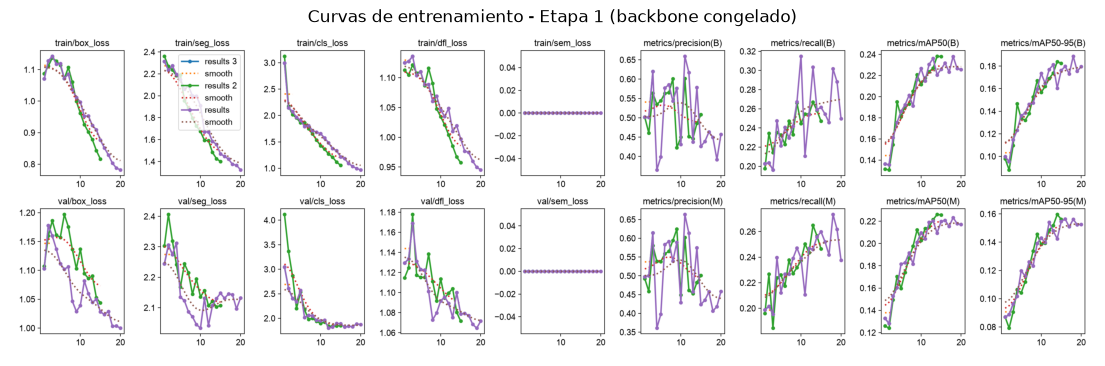

In [12]:
from PIL import Image as PILImage

results_img_path = Path("../runs/segment/residuos_yolov8seg_etapa1/results.png")
if results_img_path.exists():
    plt.figure(figsize=(14, 8))
    plt.imshow(PILImage.open(results_img_path))
    plt.axis("off")
    plt.title("Curvas de entrenamiento - Etapa 1 (backbone congelado)")
    plt.show()
else:
    print("Todavía no se generó results.png (¿terminó el entrenamiento de la etapa 1?)")


## 6. Entrenamiento — Etapa 2 (fine-tuning completo)

Retomamos desde el mejor checkpoint de la etapa 1 y descongelamos todo el
modelo, con un learning rate más bajo para hacer un ajuste fino sin
"olvidar" lo aprendido.


In [13]:
# ===== Parámetros de esta etapa (Etapa 2: fine-tuning parcial, prueba de 1 época) =====
ETAPA2_EPOCHS = 20   # antes 1, era solo para probar el ritmo
ETAPA2_IMGSZ = 960
ETAPA2_BATCH = 4
ETAPA2_LR0 = 3e-4
ETAPA2_FREEZE = 5     # congelamiento parcial (menos agresivo que Etapa 1, pero no None)
# ======================================================================

best_ckpt_etapa1 = Path("../runs/segment/residuos_yolov8seg_etapa1/weights/best.pt")
model_etapa2 = YOLO(str(best_ckpt_etapa1)) if best_ckpt_etapa1.exists() else model

try:
    wandb.init(
        project=WANDB_PROJECT,
        name="etapa2_finetuning_parcial",
        config={
            "model_base": MODEL_BASE,
            "epochs": ETAPA2_EPOCHS,
            "imgsz": ETAPA2_IMGSZ,
            "batch": ETAPA2_BATCH,
            "device": device_str,
            "etapa": "2_finetuning_parcial",
            "lr0": ETAPA2_LR0,
            "freeze": ETAPA2_FREEZE,
        },
    )
except Exception as e:
    print(f"⚠️  W&B no disponible ({e}). Se entrena sin loguear métricas a la nube.")

results_etapa2 = model_etapa2.train(
    data=DATA_YAML,
    epochs=ETAPA2_EPOCHS,
    imgsz=ETAPA2_IMGSZ,
    batch=ETAPA2_BATCH,
    device=device_str,
    project=str(Path("../runs/segment").resolve()),
    name="residuos_yolov8seg_etapa2",
    freeze=ETAPA2_FREEZE,
    lr0=ETAPA2_LR0,
    copy_paste=0.5,
    mixup=0.2,
    exist_ok=True,
)

try:
    wandb.finish()
except Exception:
    pass

New https://pypi.org/project/ultralytics/8.4.140 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.138 🚀 Python-3.13.12 torch-2.14.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/taco_yolo/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=../runs/se

/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

       1/20      6.58G     0.9977      1.925      1.776      1.067          0        134        960: 100% ━━━━━━━━━━━━ 301/301 1.5it/s 3:200.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.9it/s 19.9s0.5ss
                   all        298        951      0.557      0.229      0.164      0.121      0.545      0.224      0.154      0.102

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       2/20      5.55G     0.8808       1.96      1.601      1.106          0         47        960: 0% ──────────── 0/301  0.8s

/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

       2/20      6.58G      1.075      2.071      1.861      1.094          0          7        960: 100% ━━━━━━━━━━━━ 301/301 1.5it/s 3:160.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.9it/s 19.5s0.5s
                   all        298        951      0.519      0.214      0.143      0.106      0.518      0.212      0.139     0.0879

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       3/20      6.57G      1.065      2.506      1.978      1.134          0         41        960: 0% ──────────── 0/301  0.8s

...

      18/20      6.58G     0.7959      1.338      1.062     0.9656          0          2        960: 100% ━━━━━━━━━━━━ 301/301 1.9it/s 2:350.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.9it/s 19.9s0.5ss
                   all        298        951      0.522      0.277      0.251      0.193      0.444      0.233      0.223      0.156

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      19/20      6.57G     0.8001      1.025      1.497      1.063          0          9        960: 0% ──────────── 0/301  0.6s

/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

      19/20      6.58G     0.7767      1.344       1.01     0.9658          0          7        960: 100% ━━━━━━━━━━━━ 301/301 1.9it/s 2:350.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.9it/s 19.8s0.5ss
                   all        298        951      0.638      0.226       0.23      0.178      0.632      0.222      0.219      0.154

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      20/20      6.57G       0.57     0.5018     0.7585     0.9154          0          6        960: 0% ──────────── 0/301  0.6s

/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/venv/lib/python3.13/site-packages/torch/autograd/graph.py:1072: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/p

      20/20      6.58G     0.7647      1.307     0.9581     0.9459          0          4        960: 100% ━━━━━━━━━━━━ 301/301 1.9it/s 2:350.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.9it/s 19.9s0.5ss
                   all        298        951      0.665      0.232      0.238      0.186      0.663      0.232      0.224       0.16

20 epochs completed in 1.090 hours.
Optimizer stripped from /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/runs/segment/residuos_yolov8seg_etapa2/weights/last.pt, 23.9MB
Optimizer stripped from /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/runs/segment/residuos_yolov8seg_etapa2/weights/best.pt, 23.9MB

Validating /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/runs/segment/residuos_yolov8seg_etapa2/weights/be

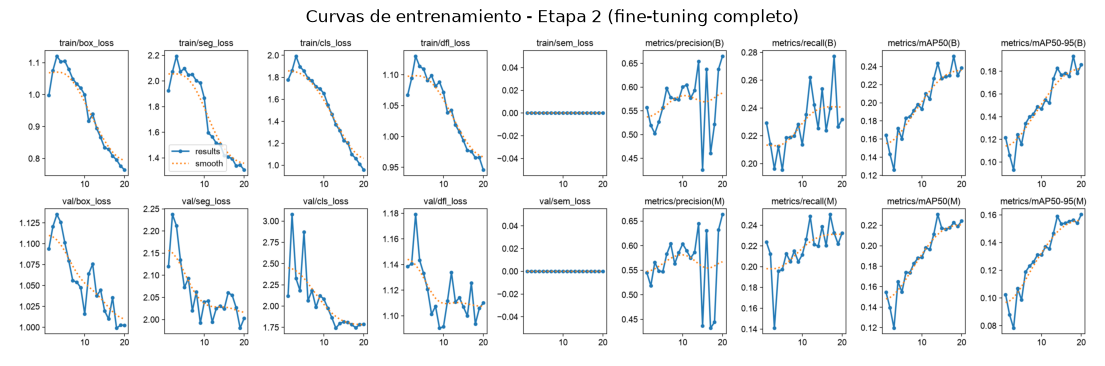

In [14]:
results_img_path = Path("../runs/segment/residuos_yolov8seg_etapa2/results.png")
if results_img_path.exists():
    plt.figure(figsize=(14, 8))
    plt.imshow(PILImage.open(results_img_path))
    plt.axis("off")
    plt.title("Curvas de entrenamiento - Etapa 2 (fine-tuning completo)")
    plt.show()


In [15]:
from pathlib import Path

runs_dir = Path("../runs/segment")

if not runs_dir.exists():
    print("❌ La carpeta ../runs/segment ni siquiera existe. El entrenamiento no llegó a crear ningún checkpoint.")
else:
    print("Carpetas encontradas en runs/segment:")
    for carpeta in sorted(runs_dir.iterdir()):
        print(f"  - {carpeta.name}")
        weights_dir = carpeta / "weights"
        if weights_dir.exists():
            for w in weights_dir.iterdir():
                print(f"      └── {w.name}")

Carpetas encontradas en runs/segment:
  - residuos_yolov8seg_etapa1
      └── last.pt
      └── best.pt
  - residuos_yolov8seg_etapa2
      └── last.pt
      └── best.pt
  - residuos_yolov8seg_etapa2_extra
      └── last.pt
      └── best.pt
  - residuos_yolov8seg_etapa2b
      └── last.pt
      └── best.pt


## 7. Evaluación del modelo

Reportamos las métricas estándar de segmentación de instancias: mAP@50,
mAP@50-95 (box y mask), y la matriz de confusión que Ultralytics genera
automáticamente durante la validación.


In [16]:
import sys
from pathlib import Path
from ultralytics import YOLO

sys.path.append(str(Path("../src").resolve()))
from device_utils import get_device_str

device_str = get_device_str()
DATA_YAML = str(Path("../data/taco_yolo/data.yaml").resolve())

# Forzamos borrado de CUALQUIER cache de labels antes de evaluar, para
# evitar que Ultralytics reutilice un split viejo de una corrida anterior.
for cache in Path("../data/taco_yolo/labels").glob("*.cache"):
    cache.unlink()
    print(f"Cache borrado: {cache}")

# Confirmamos el contenido real de data.yaml antes de evaluar
print("\n--- Contenido de data.yaml ---")
print(Path(DATA_YAML).read_text())

# Confirmamos cuántas imágenes hay REALMENTE en el folder de val
val_images = list(Path("../data/taco_yolo/images/val").glob("*"))
print(f"Imágenes reales en images/val: {len(val_images)}")

BEST_WEIGHTS = "../runs/segment/residuos_yolov8seg_etapa2/weights/best.pt"

model_final = YOLO(BEST_WEIGHTS)
metrics = model_final.val(data=DATA_YAML, device=device_str)

print("mAP50 (box):    ", metrics.box.map50)
print("mAP50-95 (box): ", metrics.box.map)
print("mAP50 (mask):   ", metrics.seg.map50)
print("mAP50-95 (mask):", metrics.seg.map)


Cache borrado: ../data/taco_yolo/labels/train.cache
Cache borrado: ../data/taco_yolo/labels/val.cache

--- Contenido de data.yaml ---
path: /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/data/taco_yolo
train: images/train
val: images/val
nc: 6
names: ['plastico', 'papel_carton', 'vidrio', 'metal', 'organico', 'otros']

Imágenes reales en images/val: 298
Ultralytics 8.4.138 🚀 Python-3.13.12 torch-2.14.0 MPS (Apple M4 Pro)
YOLOv8s-seg summary (fused): 86 layers, 11,781,922 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11012.7±2188.5 MB/s, size: 1636.3 KB)
val: Scanning /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/data/taco_yolo/labels/val... 298 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 298/298 4.5Kit/s 0.1s
val: New cache created: /Users/FedericoFernandez/Desktop/IA/Repo/vision_computadora_II-VpC2_2026/proyecto-residuos/data/taco_yolo/labels/val.ca

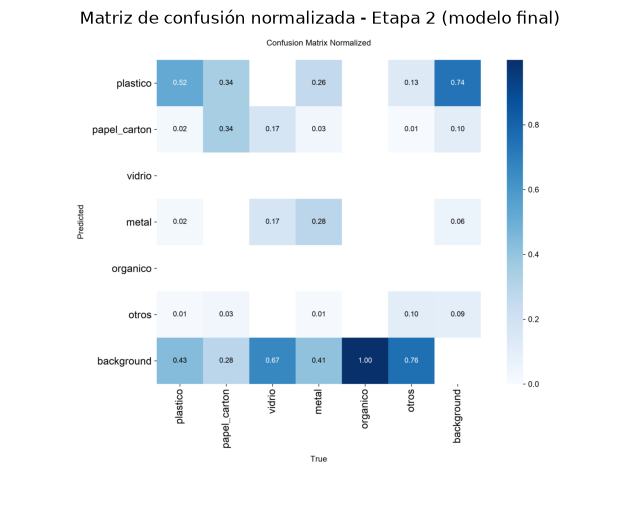

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image as PILImage

confusion_matrix_path = Path("../runs/segment/residuos_yolov8seg_etapa2/confusion_matrix_normalized.png")
if confusion_matrix_path.exists():
    plt.figure(figsize=(8, 8))
    plt.imshow(PILImage.open(confusion_matrix_path))
    plt.axis("off")
    plt.title("Matriz de confusión normalizada - Etapa 2 (modelo final)")
    plt.show()
else:
    print(f"No se encontró: {confusion_matrix_path}")


## 8. Prueba con imágenes nuevas

Corremos el modelo entrenado sobre imágenes que el modelo nunca vio (no
pertenecen a train ni a val), usando `ResiduosSegmenter` de `src/inference.py`,
que además aplica el mapeo de material -> color de contenedor de reciclaje.


[ResiduosSegmenter] Modelo cargado en dispositivo: mps


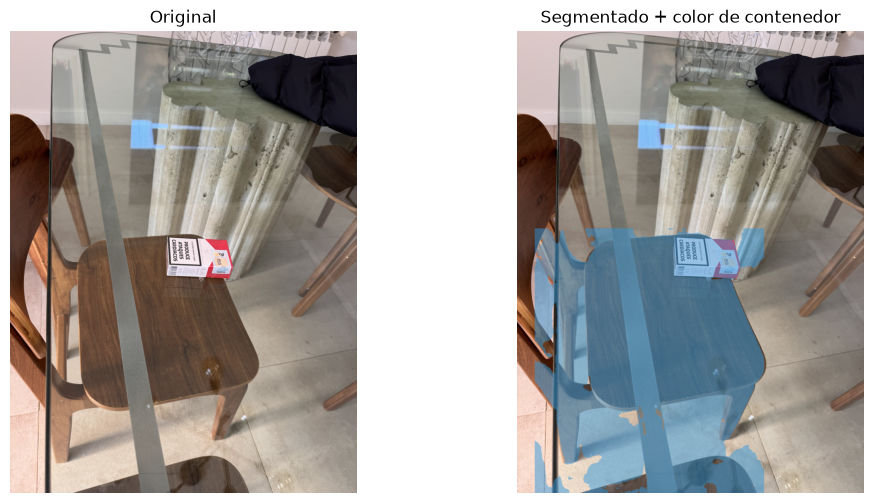

Detecciones en residuos_1.jpg:
  🔵 Papel_carton → Tacho Azul (74%)



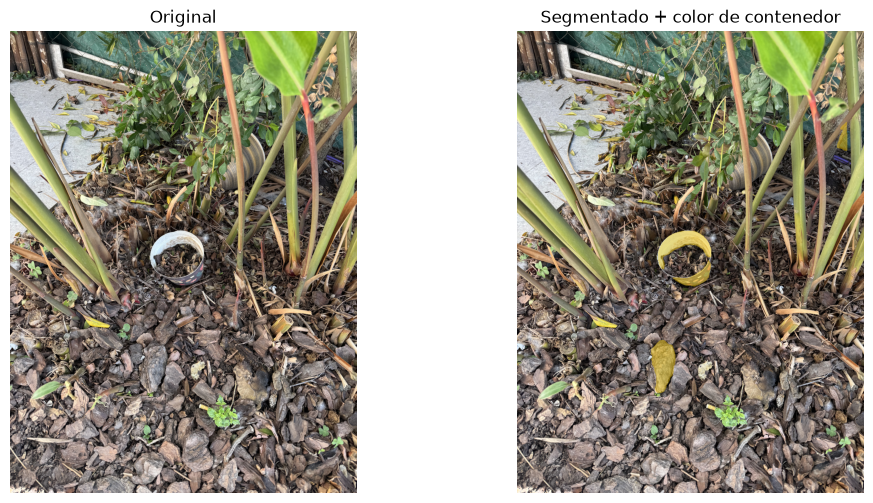

Detecciones en residuos_2.jpg:
  🟡 Plastico → Tacho Amarillo (67%)
  🟡 Plastico → Tacho Amarillo (62%)
  🟡 Plastico → Tacho Amarillo (60%)



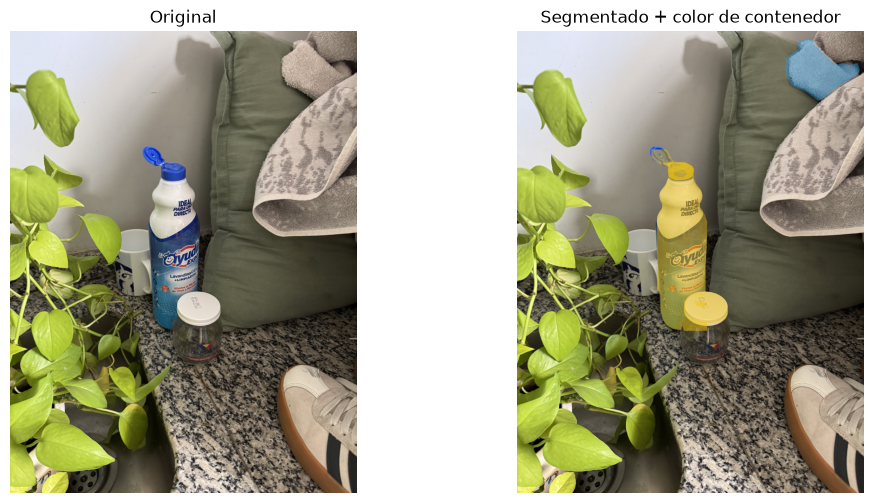

Detecciones en residuos_3.jpg:
  🟡 Plastico → Tacho Amarillo (88%)
  🟡 Plastico → Tacho Amarillo (84%)
  🟡 Plastico → Tacho Amarillo (67%)
  🔵 Papel_carton → Tacho Azul (57%)
  🟡 Plastico → Tacho Amarillo (51%)



In [2]:
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

sys.path.append(str(Path("../src").resolve()))
from inference import ResiduosSegmenter
from device_utils import get_device_str

device_str = get_device_str()
BEST_WEIGHTS = "../runs/segment/residuos_yolov8seg_etapa2/weights/best.pt"

segmenter = ResiduosSegmenter(BEST_WEIGHTS, device=device_str)

# Reemplazar por paths a imágenes propias de prueba
imagenes_prueba = [
    "../imagenes_prueba/residuos_1.jpg",
    "../imagenes_prueba/residuos_2.jpg",
     "../imagenes_prueba/residuos_3.jpg",
]

for img_path in imagenes_prueba:
    if not Path(img_path).exists():
        print(f"(no encontrada, saltando): {img_path}")
        continue

    img_bgr = cv2.imread(img_path)
    overlay_rgb, detections = segmenter.predict_image(img_bgr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(overlay_rgb)
    axes[1].set_title("Segmentado + color de contenedor")
    axes[1].axis("off")
    plt.show()

    print(f"Detecciones en {Path(img_path).name}:")
    for d in detections:
        print(f"  {d['label']}")
    print()


## 9. Conclusiones

1. **La cantidad de datos disponibles fue el factor más determinante en el desempeño del modelo.** El mAP50 (máscara) global mejoró de forma consistente a medida que se completó la descarga del dataset TACO: de 0.110 (~85 imágenes parciales, por enlaces de Flickr caídos) a 0.173 (895 imágenes) y finalmente 0.223 (1500 imágenes completas, obtenidas desde el mirror oficial en Zenodo). Esto confirma que, para este tipo de tarea, invertir en completar y curar el dataset tuvo más impacto que ajustar hiperparámetros del modelo.

2. **Las clases con pocas instancias (`vidrio`, `organico`) no lograron ser aprendidas por el modelo, independientemente de los ajustes realizados.** A pesar de que `vidrio` pasó de 3 a 148 instancias totales al completar el dataset, su mAP50 se mantuvo cercano a 0 en todas las corridas. `organico`, con solo 8 instancias en todo el dataset, es una limitación estructural de TACO (un dataset de litter en contextos naturales, donde los residuos orgánicos son raros por descomponerse rápidamente) y no del enfoque de entrenamiento.

3. **Un split aleatorio simple por imagen puede desbalancear severamente clases minoritarias entre train y validación.** Se detectó que, en una corrida, el 56% de las instancias de `vidrio` terminaron en el conjunto de validación por pura casualidad, dejando muy pocas para entrenar. Se implementó un split estratificado (agrupando imágenes por su clase macro más escasa) que mejoró el balance para la mayoría de las clases a ~20% en validación, aunque `vidrio` siguió siendo sensible a la variabilidad de instancias por imagen dado su bajo volumen total.

4. **La resolución de entrada (`imgsz`) tuvo más impacto que descongelar completamente el backbone.** Al comparar estrategias de fine-tuning, una Etapa 2 con `imgsz=640` y todo el modelo descongelado rindió peor (mAP50=0.205) que la Etapa 1 con `imgsz=960` y backbone congelado (mAP50=0.226). Recién al recuperar `imgsz=960` combinado con un congelamiento parcial (`freeze=5`, en vez de `None`) —una solución de compromiso para evitar saturar la memoria unificada del hardware disponible (Mac M4 Pro)— la Etapa 2 logró igualar y superar levemente a la Etapa 1 en las clases con mayor volumen de datos (`plastico`, `metal`).

5. **El resultado final (mAP50-95 ≈ 0.16) es comparable al reportado por los propios autores de TACO** utilizando Mask R-CNN sobre 10 clases (AP=19.4, Proença & Simões, 2020), a pesar de emplear un modelo más liviano (YOLOv8-seg) y significativamente menos recursos de entrenamiento. Ambos trabajos coinciden en identificar la escasez de instancias por clase y la confusión entre clases visualmente similares como las principales limitaciones.

6. **La matriz de confusión reveló que el error dominante del modelo es la omisión de objetos (falsos negativos hacia `background`), no la confusión entre clases.** Clases como `vidrio` (67% clasificado como background), `organico` (100%) y `otros` (76%) fueron mayormente "invisibles" para el modelo, mientras que la confusión entre clases reales (ej. `metal`↔`vidrio`, 17%) fue comparativamente menor. Esto sugiere que futuras mejoras deberían priorizar aumentar el recall (más datos, ajuste de umbral de confianza) antes que refinar la discriminación entre clases.

7. **Se identificó un fuerte efecto de "domain shift" al probar el modelo con fotos propias fuera del dominio de TACO.** En escenas de exterior con tierra/vegetación (similares al contexto de litter de TACO), las máscaras predichas se ajustaron correctamente a los objetos reales. En cambio, en un ambiente doméstico interior (living, muebles), el modelo produjo una máscara mal ubicada que cubría una región mucho mayor al objeto real, aunque acertó la clasificación del material. Esto confirma que el desempeño depende fuertemente de la similitud entre el contexto de despliegue y la distribución de datos de entrenamiento.

## Trabajo futuro

- Sumar imágenes de datasets complementarios (ej. DWSD, con más instancias de vidrio) o de captura propia, específicamente para las clases `vidrio` y `organico`.
- Explorar un split verdaderamente estratificado por instancia (no solo por imagen), o técnicas de reponderación de clases en la loss.
- Evaluar arquitecturas de doble modelo especializado por contexto de uso: uno entrenado sobre TACO (litter en escenas naturales) y otro sobre TrashNet (ítem único, fondo controlado), seleccionable desde el front según el escenario de captura.
- Probar learning rates diferenciales por grupo de capas (backbone vs. head) como alternativa más fina al congelamiento binario de capas, si se dispone de una API de entrenamiento que lo soporte directamente.
- Validar y eventualmente reentrenar el modelo con imágenes capturadas en el escenario de despliegue real (ej. cámara sobre un tacho, ítem sostenido manualmente), dado el domain shift observado respecto a TACO.